# Create dataset

In [ ]:
!pip -q install pybullet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 4.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pybullet as p
import pybullet_data
import imageio
from pathlib import Path
from PIL import Image
import os
from IPython.display import Image as IPyImage
import uuid

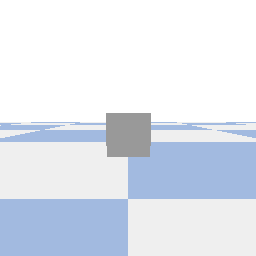

In [ ]:
def generate_occlusion_sim(
    gif_path="scene.gif",
    ball_start=(-1.0, 0, 0.05),
    force_vector=(100, 0, 0),
    barrier_position=(0.0, 0, 0.1),
    frame_count=150,
    image_size=256,
    fps=10
):
    p.connect(p.DIRECT)
    p.setAdditionalSearchPath(pybullet_data.getDataPath())
    p.setGravity(0, 0, -9.8)

    # Load ground and ball
    p.loadURDF("plane.urdf")
    ball = p.loadURDF("sphere_small.urdf", basePosition=ball_start)
    p.stepSimulation()
    p.applyExternalForce(ball, -1, force_vector, [0, 0, 0], p.WORLD_FRAME)

    barrier_half_width = 0.1
    barrier_x = barrier_position[0]
    ball_radius = 0.05  # default radius in sphere_small.urdf

    # Visual-only occluder (no collision)
    visual_shape = p.createVisualShape(
        shapeType=p.GEOM_BOX,
        halfExtents=[barrier_half_width, 0.5, 0.1],
        rgbaColor=[1, 1, 1, 1]
    )
    p.createMultiBody(
        baseMass=0,
        baseCollisionShapeIndex=-1,
        baseVisualShapeIndex=visual_shape,
        basePosition=barrier_position
    )

    # Camera setup
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=[0.0, -1.5, 0.2],
        cameraTargetPosition=[0.0, 0.0, 0.1],
        cameraUpVector=[0, 0, 1]
    )
    proj_matrix = p.computeProjectionMatrixFOV(60, 1.0, 0.01, 5)

    frames = []
    metadata = []

    # Apply damping and lock rotation
    p.changeDynamics(ball, -1, linearDamping=0, angularDamping=1)

    os.makedirs("frames", exist_ok=True)

    for frame_idx in range(frame_count):
        p.stepSimulation()
        _, _, rgb, _, _ = p.getCameraImage(image_size, image_size, view_matrix, proj_matrix)
        frame = np.reshape(rgb, (image_size, image_size, 4))[:, :, :3]
        frames.append(frame.astype(np.uint8))

        # Track position and velocity
        pos, _ = p.getBasePositionAndOrientation(ball)
        vel, _ = p.getBaseVelocity(ball)

        ball_x = pos[0]
        occluded = (barrier_x - barrier_half_width - ball_radius) < ball_x < (barrier_x + barrier_half_width + ball_radius)

        # Save the frame
        Image.fromarray(frame).save(f"frames/frame_{frame_idx:04d}.png")

        metadata.append({
            'frame': frame_idx,
            'x': pos[0], 'y': pos[1], 'z': pos[2],
            'vx': vel[0], 'vy': vel[1], 'vz': vel[2],
            'occluded': occluded,
        })

    scene_metadata = {
        "gif_path": gif_path,
        "ball_start": ball_start,
        "force_vector": force_vector,
        "barrier_position": barrier_position,
        "barrier_half_width": barrier_half_width,
        "ball_radius": ball_radius,
        "frame_count": frame_count,
        "fps": fps,
        "image_size": image_size,
        "camera_eye_position": [0.0, -1.5, 0.2],
        "camera_target_position": [0.0, 0.0, 0.1],
        "scene_id": f"scene_{uuid.uuid4().hex[:8]}"
    }

    imageio.mimsave(gif_path, frames, fps=fps)
    p.disconnect()
    return gif_path, metadata, scene_metadata

# Run and display
gif_path, metadata, scene_metadata = generate_occlusion_sim()

# derived metadata
occlusion_frames = [m["frame"] for m in metadata if m["occluded"]]
if occlusion_frames:
    scene_metadata["occlusion_start_frame"] = min(occlusion_frames)
    scene_metadata["occlusion_end_frame"] = max(occlusion_frames)
    scene_metadata["reappearance_frame"] = scene_metadata["occlusion_end_frame"] + 1
    scene_metadata["visible_before_occlusion_frames"] = scene_metadata["occlusion_start_frame"]

IPyImage(filename=gif_path)

In [ ]:
import os
import json
import csv
import uuid
import shutil


def save_simulation_outputs(gif_path: str, metadata: list[dict], scene_params: dict, output_dir="occlusion_experiments") -> str:
    """
    Save GIF, per-frame metadata, and scene-level metadata.

    Args:
        gif_path (str): Path to the saved GIF file.
        metadata (list[dict]): Per-frame ball metadata.
        scene_params (dict): Metadata about the simulation configuration.
        output_dir (str): Top-level directory to save everything.

    Returns:
        str: Path to the scene directory.
    """
    # Generate unique scene ID
    scene_id = scene_params.get("scene_id", f"scene_{uuid.uuid4().hex[:8]}")
    scene_dir = os.path.join(output_dir, scene_id)
    os.makedirs(scene_dir, exist_ok=True)

    # Move the GIF into the folder
    new_gif_path = os.path.join(scene_dir, Path(gif_path).name)
    os.replace(gif_path, new_gif_path)

    # Move frame directory if it exists
    frame_dir = Path("frames")
    if frame_dir.exists() and frame_dir.is_dir():
        new_frame_dir = scene_dir + "/frames"
        if os.path.exists(new_frame_dir):
            shutil.rmtree(new_frame_dir)
        shutil.move(str(frame_dir), new_frame_dir)

    # Save per-frame metadata as CSV
    csv_path = os.path.join(scene_dir, "frame_data.csv")
    with open(csv_path, mode="w", newline="") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=metadata[0].keys())
        writer.writeheader()
        writer.writerows(metadata)

    # Optional: infer occlusion stats
    occlusion_frames = [m["frame"] for m in metadata if m["occluded"]]
    if occlusion_frames:
        scene_params.update({
            "occlusion_start_frame": min(occlusion_frames),
            "occlusion_end_frame": max(occlusion_frames),
            "visible_before_occlusion_frames": min(occlusion_frames),
            "reappearance_frame": max(occlusion_frames) + 1
        })

    # Save scene metadata as JSON
    json_path = os.path.join(scene_dir, "scene_metadata.json")
    with open(json_path, "w") as f:
        json.dump(scene_params, f, indent=2)

    print(f"[✓] Saved simulation to {scene_dir}")
    return scene_dir

gif_path, metadata, scene_metadata = generate_occlusion_sim()
scene_dir = save_simulation_outputs(gif_path, metadata, scene_metadata)

[✓] Saved simulation to occlusion_experiments/scene_c2955662


In [ ]:
# from PIL import Image, ImageSequence
# import os

# def gif_to_pngs(gif_path, output_dir):
#     os.makedirs(output_dir, exist_ok=True)
#     with Image.open(gif_path) as im:
#         for i, frame in enumerate(ImageSequence.Iterator(im)):
#             frame.convert("RGBA").save(os.path.join(output_dir, f"frame_{i:04d}.png"))

# frame_dir = scene_dir / Path("output_frames")
# gif_to_pngs(scene_dir / Path(gif_path), frame_dir)
# print(f"[✓] Saved {len(list(frame_dir.glob('*.png')))} frames to {frame_dir}")

In [ ]:
# !mkdir -p frames
# !ffmpeg -i {str(scene_dir / Path(gif_path))} -vsync 0 frames/frame_%03d.png

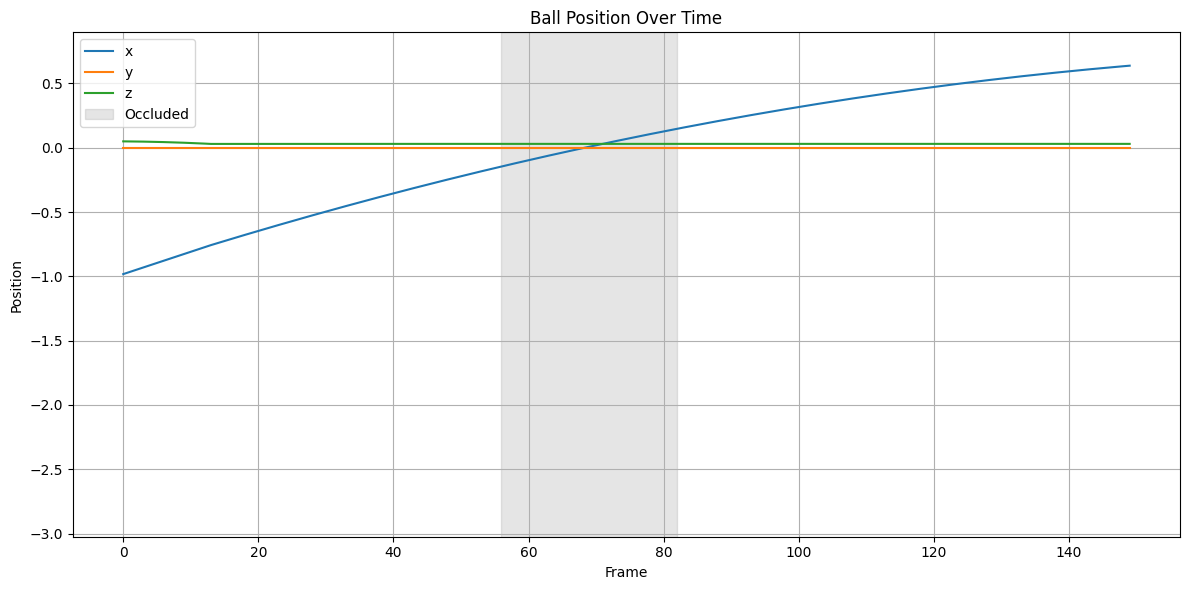

In [ ]:
import matplotlib.pyplot as plt
import json
import pandas as pd

df = pd.DataFrame(metadata)

# Plot x, y, z over time
plt.figure(figsize=(12, 6))
plt.plot(df['frame'], df['x'], label='x')
plt.plot(df['frame'], df['y'], label='y')
plt.plot(df['frame'], df['z'], label='z')
plt.fill_between(df['frame'], -1, 1, where=df['occluded'], color='gray',
                 alpha=0.2, transform=plt.gca().get_xaxis_transform(), label='Occluded')
plt.xlabel('Frame')
plt.ylabel('Position')
plt.title('Ball Position Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

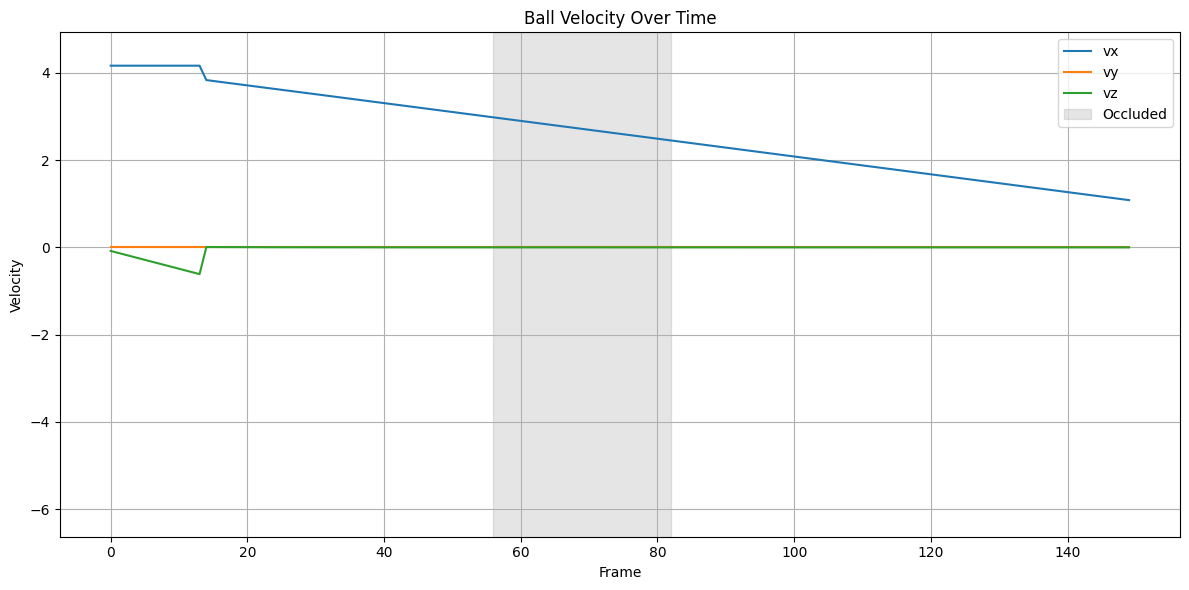

In [ ]:
# Plot vx, vy, vz over time
plt.figure(figsize=(12, 6))
plt.plot(df['frame'], df['vx'], label='vx')
plt.plot(df['frame'], df['vy'], label='vy')
plt.plot(df['frame'], df['vz'], label='vz')
plt.fill_between(df['frame'], -1, 1, where=df['occluded'], color='gray',
                 alpha=0.2, transform=plt.gca().get_xaxis_transform(), label='Occluded')
plt.xlabel('Frame')
plt.ylabel('Velocity')
plt.title('Ball Velocity Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Copy to Drive

In [ ]:
!cp -r /content/occlusion_experiments "/content/drive/My Drive/Colab Notebooks/intuitive physics/data/"